In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/Walls.zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Streaming output truncated to the last 5000 lines.
/content/unzipped_folder/Walls/Non-cracked/7139-103.jpg
/content/unzipped_folder/Walls/Non-cracked/7140-45.jpg
/content/unzipped_folder/Walls/Non-cracked/7135-121.jpg
/content/unzipped_folder/Walls/Non-cracked/7138-193.jpg
/content/unzipped_folder/Walls/Non-cracked/7130-234.jpg
/content/unzipped_folder/Walls/Non-cracked/7138-187.jpg
/content/unzipped_folder/Walls/Non-cracked/7131-222.jpg
/content/unzipped_folder/Walls/Non-cracked/7071-211.jpg
/content/unzipped_folder/Walls/Non-cracked/7133-201.jpg
/content/unzipped_folder/Walls/Non-cracked/7131-226.jpg
/content/unzipped_folder/Walls/Non-cracked/7117-94.jpg
/content/unzipped_folder/Walls/Non-cracked/7074-18.jpg
/content/unzipped_folder/Walls/Non-cracked/7082-146.jpg
/content/unzipped_folder/Walls/Non-cracked/7138-69.jpg
/content/unzipped_folder/Walls/Non-cracked/7125-214.jpg
/content/unzipped_folder/Walls/Non-cracked/7086-220.jpg
/content/unzipped_folder/Walls/Non-cracked/7074-252.jpg
/

Found 14511 images belonging to 2 classes.
Found 3627 images belonging to 2 classes.


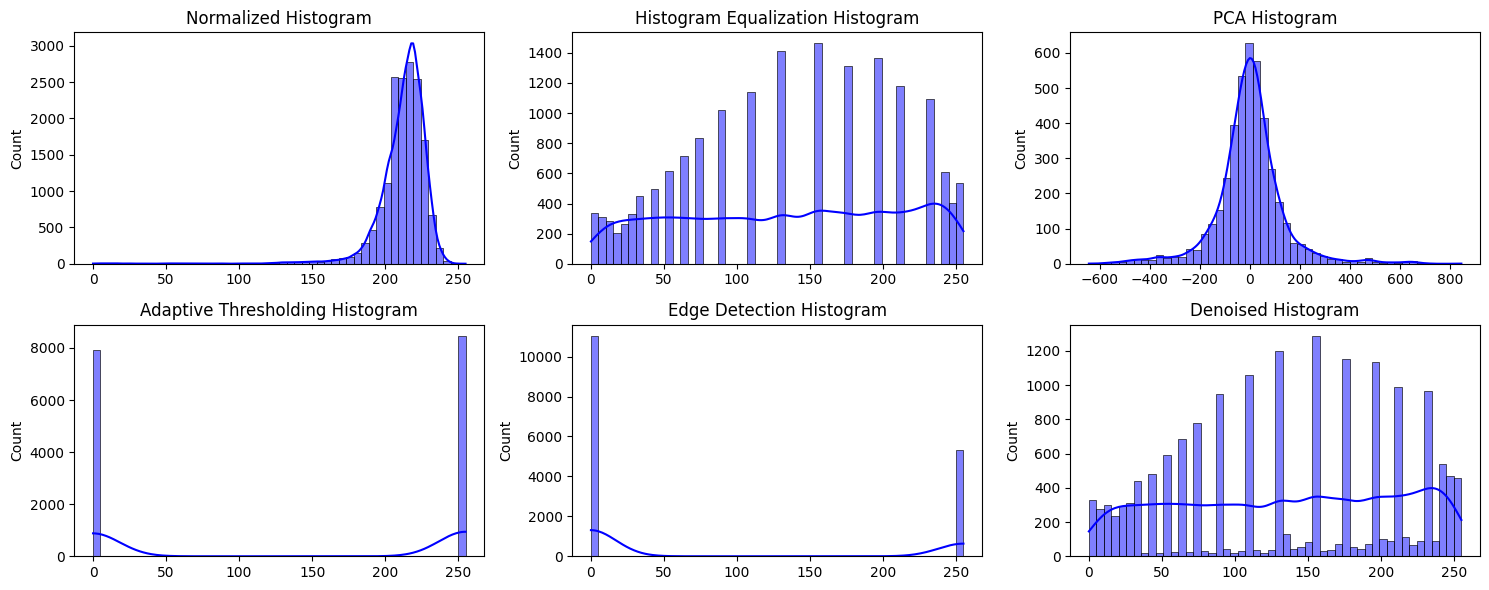

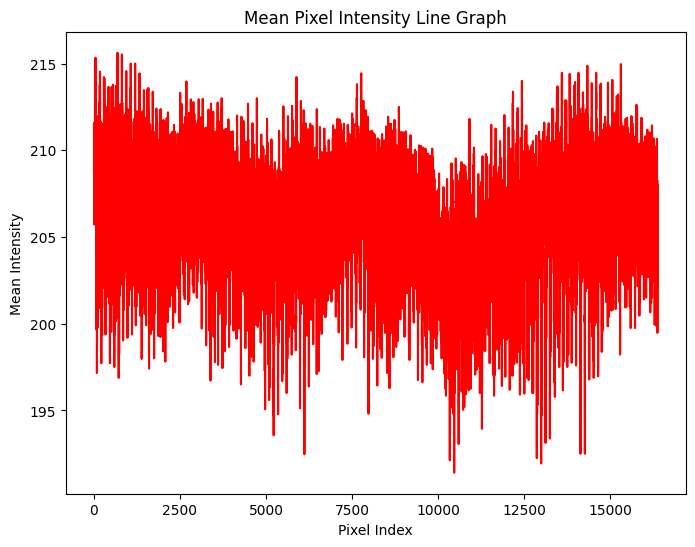

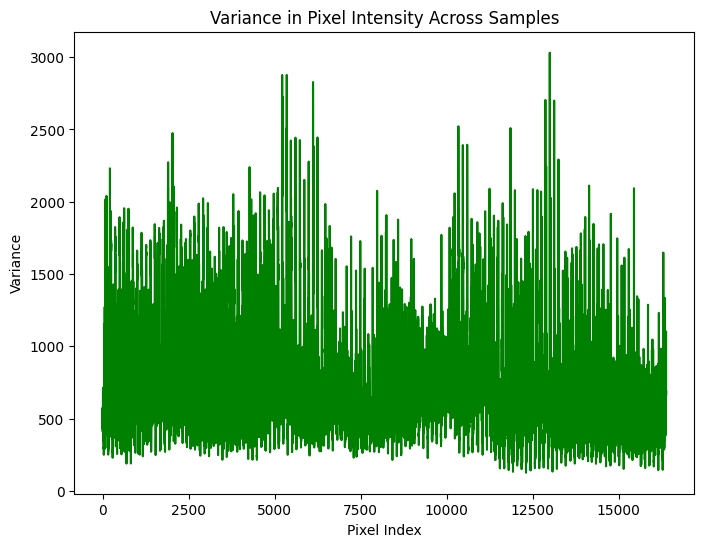

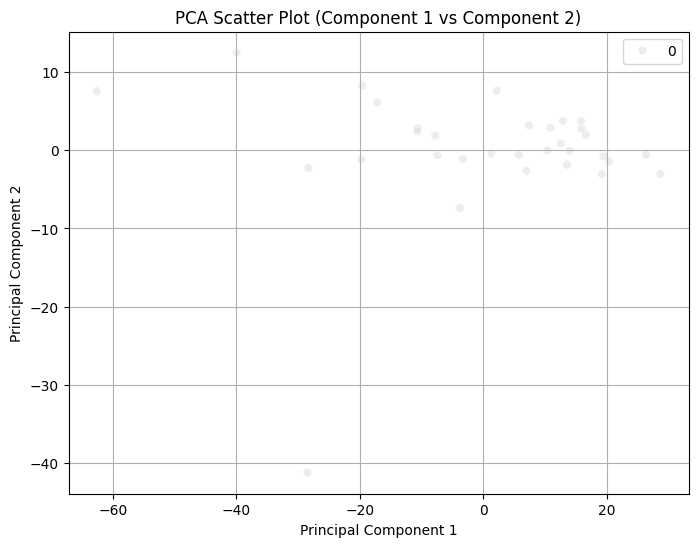

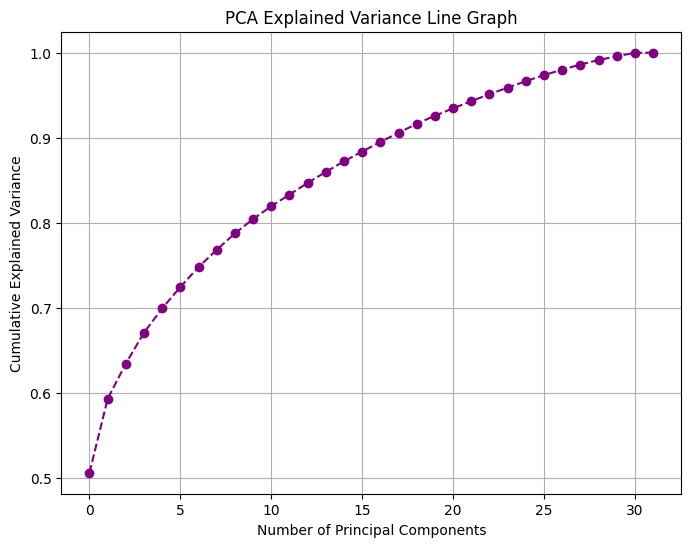

In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.decomposition import PCA
from skimage import exposure
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Define Paths
base_dir = "/content/unzipped_folder"  # Change if needed
IMG_SIZE = (128, 128)  # Resize images
BATCH_SIZE = 32

# Image Data Generator for Augmentation & Normalization
datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalization
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

# Load dataset
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

# Extract batch of images and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Function: Apply Preprocessing Steps
def preprocess_image(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Contrast & Brightness Normalization
    normalized = cv2.normalize(gray, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    # Histogram Equalization
    hist_eq = cv2.equalizeHist(normalized)

    # Principal Component Analysis (PCA) for Dimensionality Reduction
    pca = PCA(n_components=0.95)
    img_pca = pca.fit_transform(hist_eq)

    # Adaptive Thresholding
    adaptive_thresh = cv2.adaptiveThreshold(hist_eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    # Edge Detection (Canny)
    edges = cv2.Canny(hist_eq, 50, 150)

    # Denoising
    denoised = cv2.fastNlMeansDenoising(hist_eq, None, 10, 7, 21)

    return {
        "Normalized": normalized,
        "Histogram Equalization": hist_eq,
        "PCA": img_pca,
        "Adaptive Thresholding": adaptive_thresh,
        "Edge Detection": edges,
        "Denoised": denoised
    }

# Extract features and labels from dataset
X_train_processed = []
X_val_processed = []
y_train_labels = []
y_val_labels = []

for i in range(len(X_train)):
    processed = preprocess_image((X_train[i] * 255).astype(np.uint8))
    X_train_processed.append(processed["Normalized"].flatten())  # Use flattened normalized image
    y_train_labels.append(y_train[i])  # Labels

for i in range(len(X_val)):
    processed = preprocess_image((X_val[i] * 255).astype(np.uint8))
    X_val_processed.append(processed["Normalized"].flatten())
    y_val_labels.append(y_val[i])

X_train_processed = np.array(X_train_processed)
X_val_processed = np.array(X_val_processed)

# Normalize the extracted features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

# Encode Labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels)
y_val_encoded = label_encoder.transform(y_val_labels)

# Graphical Representation of Feature Distributions
plt.figure(figsize=(15, 6))

for i, (key, img) in enumerate(preprocess_image((X_train[0] * 255).astype(np.uint8)).items()):
    plt.subplot(2, 3, i+1)
    sns.histplot(img.ravel(), bins=50, kde=True, color="blue")
    plt.title(f"{key} Histogram")

plt.tight_layout()
plt.show()

# Plot Mean Pixel Intensities
plt.figure(figsize=(8, 6))
mean_pixel_intensity = np.mean(X_train_processed, axis=0)
plt.plot(mean_pixel_intensity, color='red')
plt.title("Mean Pixel Intensity Line Graph")
plt.xlabel("Pixel Index")
plt.ylabel("Mean Intensity")
plt.show()

# Plot Variance in Pixel Intensity
plt.figure(figsize=(8, 6))
pixel_variance = np.var(X_train_processed, axis=0)
plt.plot(pixel_variance, color='green')
plt.title("Variance in Pixel Intensity Across Samples")
plt.xlabel("Pixel Index")
plt.ylabel("Variance")
plt.show()

# PCA Scatter Plot using Scaled Data (Component 1 vs Component 2)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_transformed[:, 0], y=pca_transformed[:, 1], hue=y_train_encoded, palette="coolwarm", alpha=0.5)
plt.title("PCA Scatter Plot (Component 1 vs Component 2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


# 🔹 PCA Explained Variance Line Graph
pca_full = PCA().fit(X_train_scaled)
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='purple')
plt.title("PCA Explained Variance Line Graph")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()
